<a href="https://colab.research.google.com/github/priyanshi29bhardwaj/MLlab/blob/main/Test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***NAIVE BAYES CLASSIFIER:***

In [1]:
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving emails.csv to emails.csv


In [22]:
# Load dataset
df = pd.read_csv('emails.csv')

# Check data
df.head()


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


**Text Preprocessing**

In [7]:
df = df.dropna()  #remove missing rows

In [12]:
print(df.columns)

Index(['text', 'spam'], dtype='object')


In [23]:
# Separate features and target
X = df['text']
y = df['spam']

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
X = cv.fit_transform(X).toarray()

**Train Test Split**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

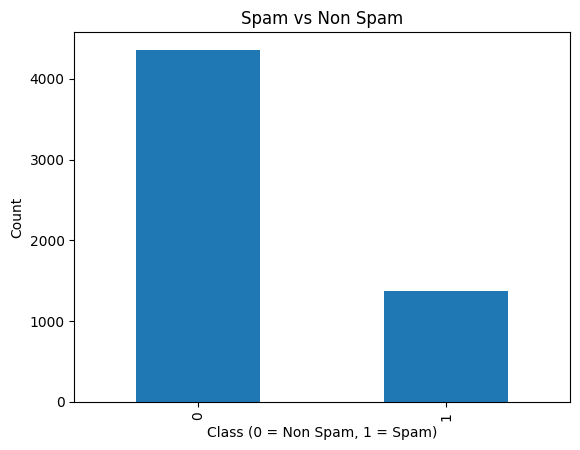

In [19]:
import matplotlib.pyplot as plt

df['spam'].value_counts().plot(kind='bar')
plt.title("Spam vs Non Spam")
plt.xlabel("Class (0 = Non Spam, 1 = Spam)")
plt.ylabel("Count")
plt.show()

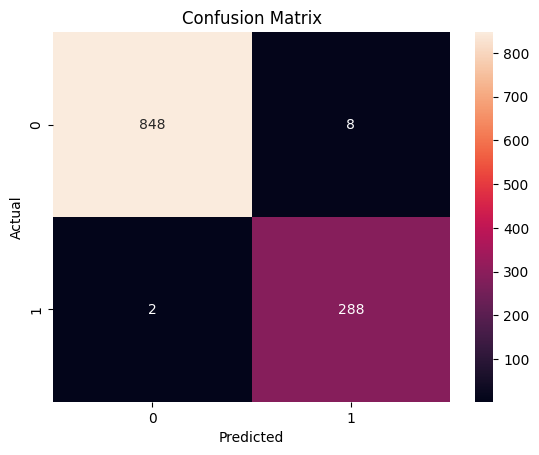

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9912739965095986
